## 공통함수 삽입

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.tree import export_graphviz
import graphviz
from subprocess import call
from IPython.display import Image
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from statsmodels.api import Logit
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')
import os
os.chdir("/home/piai/Desktop/git/2. Big Data 분석")

import warnings
warnings.filterwarnings('ignore')

In [2]:
matplotlib.rc("font", family = "NanumSquare")
matplotlib.rc("axes", unicode_minus = False)

## 데이터 구성

In [3]:
df_raw = pd.read_csv("통신고객이탈.csv")
df_raw

,CHURN,CUSTOMER_ID,GENDER,AGE,CHARGE_TYPE,HANDSET,USAGE_BAND,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME
0,Active,K102990,F,31,CAT 100,ASAD170,Med,33.33,6,218,379.8,9,21.6,366,632.4
1,Active,K103280,M,27,CAT 100,S50,Med,30.87,10,373,656.4,11,28.0,411,810.4
2,Active,K103660,M,27,CAT 100,ASAD170,Med,49.40,11,260,582.0,0,0.0,265,614.1
3,Active,K103730,M,61,CAT 100,ASAD170,Med,48.60,1,294,661.8,14,101.5,326,844.0
4,Active,K104560,F,52,CAT 100,S50,Med,56.03,0,221,555.6,7,25.0,274,673.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925,Churned,K413330,M,19,Play 100,SOP10,Med,17.40,12,60,100.8,27,59.4,127,628.2
926,Churned,K413410,F,59,Play 100,SOP20,Med,17.37,15,82,130.2,12,25.8,357,650.7
927,Churned,K415490,F,33,Play 300,S50,Med,44.93,12,174,286.2,25,67.0,596,1039.0
928,Churned,K415880,F,25,Play 300,S50,Med,40.43,14,315,552.0,0,0.0,609,1188.3


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CHURN               930 non-null    object 
 1   CUSTOMER_ID         930 non-null    object 
 2   GENDER              930 non-null    object 
 3   AGE                 930 non-null    int64  
 4   CHARGE_TYPE         930 non-null    object 
 5   HANDSET             930 non-null    object 
 6   USAGE_BAND          930 non-null    object 
 7   SERVICE_DURATION    930 non-null    float64
 8   DROPPED_CALLS       930 non-null    int64  
 9   PEAK_CALLS_NO       930 non-null    int64  
 10  PEAK_CALLS_TIME     930 non-null    float64
 11  WEEKEND_CALLS_NO    930 non-null    int64  
 12  WEEKEND_CALLS_TIME  930 non-null    float64
 13  TOTAL_CALLS_NO      930 non-null    int64  
 14  TOTAL_CALLS_TIME    930 non-null    float64
dtypes: float64(4), int64(5), object(6)
memory usage: 109.1+ K

In [5]:
df_raw.isnull().sum()

CHURN                 0
CUSTOMER_ID           0
GENDER                0
AGE                   0
CHARGE_TYPE           0
HANDSET               0
USAGE_BAND            0
SERVICE_DURATION      0
DROPPED_CALLS         0
PEAK_CALLS_NO         0
PEAK_CALLS_TIME       0
WEEKEND_CALLS_NO      0
WEEKEND_CALLS_TIME    0
TOTAL_CALLS_NO        0
TOTAL_CALLS_TIME      0
dtype: int64

In [6]:
#결측치를 인식하지 못하여 처리
df_raw['USAGE_BAND'].replace("None", np.nan, inplace=True)
df_raw['USAGE_BAND'].fillna(df_raw['USAGE_BAND'].mode()[0], inplace=True)

In [7]:
df_raw['CHURN'].replace({'Churned': 1, 'Active': 0}, inplace = True)
df_raw.drop(["CUSTOMER_ID"], axis =1, inplace = True)
df_raw

,CHURN,GENDER,AGE,CHARGE_TYPE,HANDSET,USAGE_BAND,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME
0,0,F,31,CAT 100,ASAD170,Med,33.33,6,218,379.8,9,21.6,366,632.4
1,0,M,27,CAT 100,S50,Med,30.87,10,373,656.4,11,28.0,411,810.4
2,0,M,27,CAT 100,ASAD170,Med,49.40,11,260,582.0,0,0.0,265,614.1
3,0,M,61,CAT 100,ASAD170,Med,48.60,1,294,661.8,14,101.5,326,844.0
4,0,F,52,CAT 100,S50,Med,56.03,0,221,555.6,7,25.0,274,673.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925,1,M,19,Play 100,SOP10,Med,17.40,12,60,100.8,27,59.4,127,628.2
926,1,F,59,Play 100,SOP20,Med,17.37,15,82,130.2,12,25.8,357,650.7
927,1,F,33,Play 300,S50,Med,44.93,12,174,286.2,25,67.0,596,1039.0
928,1,F,25,Play 300,S50,Med,40.43,14,315,552.0,0,0.0,609,1188.3


## 로지스틱 회귀분석

### 데이터 분할

In [8]:
df_train, df_test = train_test_split(df_raw, test_size = 0.3, random_state = 1234)

print("train data shape: ", df_train.shape)
print("test data shape: ", df_test.shape)

train data shape:  (651, 14)
test data shape:  (279, 14)


### 모델 생성

In [9]:
log_model = Logit.from_formula("""CHURN ~ C(GENDER) + AGE + C(CHARGE_TYPE) + C(HANDSET) + C(USAGE_BAND) + SERVICE_DURATION +
                                            DROPPED_CALLS + PEAK_CALLS_NO + PEAK_CALLS_TIME + WEEKEND_CALLS_NO + WEEKEND_CALLS_TIME +
                                            TOTAL_CALLS_NO + TOTAL_CALLS_TIME""", df_train)

log_result = log_model.fit()

print(log_result.summary())

         Current function value: 0.253386
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                  CHURN   No. Observations:                  651
Model:                          Logit   Df Residuals:                      622
Method:                           MLE   Df Model:                           28
Date:                Fri, 31 Oct 2025   Pseudo R-squ.:                  0.5056
Time:                        01:39:51   Log-Likelihood:                -164.95
converged:                      False   LL-Null:                       -333.64
Covariance Type:            nonrobust   LLR p-value:                 8.551e-55
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                    -24.1937   2032.752     -0.012      0.991   -4008.313    3959.926
C(GENDER)[T.M]   

In [10]:
#변수가 너무 적어 임계값을 증가
log_model = Logit.from_formula("""CHURN ~ AGE + C(CHARGE_TYPE) + C(USAGE_BAND) + SERVICE_DURATION +
                                DROPPED_CALLS + PEAK_CALLS_TIME """, df_train)
log_result = log_model.fit()

print(log_result.summary())

Optimization terminated successfully.
         Current function value: 0.458228
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  CHURN   No. Observations:                  651
Model:                          Logit   Df Residuals:                      638
Method:                           MLE   Df Model:                           12
Date:                Fri, 31 Oct 2025   Pseudo R-squ.:                  0.1059
Time:                        01:39:51   Log-Likelihood:                -298.31
converged:                       True   LL-Null:                       -333.64
Covariance Type:            nonrobust   LLR p-value:                 2.397e-10
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -1.7863      1.065     -1.678      0.093      

### 모델 예측

In [11]:
y_pred_train = log_result.predict(df_train)

y_pred_train_class = (y_pred_train > 0.5).astype(int)
print("Train 예측 결과 \n", y_pred_train_class.head(), "\n")
print("Confusion Matrix: \n{}".format(confusion_matrix(df_train["CHURN"],y_pred_train_class)),"\n")

y_pred_test = log_result.predict(df_test)

y_pred_test_class = (y_pred_test > 0.5).astype(int)
print("Test 예측 결과 \n", y_pred_test_class[10:15].head())
print("Confusion Matrix: \n{}".format(confusion_matrix(df_test["CHURN"],y_pred_test_class)),"\n")

Train 예측 결과 
 64     0
201    0
37     0
403    0
322    0
dtype: int64 

Confusion Matrix: 
[[505  10]
 [108  28]] 

Test 예측 결과 
 681    0
622    0
137    0
29     0
60     0
dtype: int64
Confusion Matrix: 
[[226   9]
 [ 36   8]] 



### 모델 평가

In [12]:
print("Train 예측/분류 결과")
print("Accuracy: {0:.3f}\n".format(accuracy_score(df_train["CHURN"], y_pred_train_class)))
print("Confusion Matrix: \n{}".format(confusion_matrix(df_train["CHURN"],y_pred_train_class)),"\n")
print(classification_report(df_train["CHURN"], y_pred_train_class, digits=3))

print("Test 예측/분류 결과")
print("Accuracy: {0:.3f}\n".format(accuracy_score(df_test["CHURN"], y_pred_test_class)))
print("Confusion Matrix: \n{}".format(confusion_matrix(df_test["CHURN"],y_pred_test_class)),"\n")
print(classification_report(df_test["CHURN"], y_pred_test_class, digits=3))

Train 예측/분류 결과
Accuracy: 0.819

Confusion Matrix: 
[[505  10]
 [108  28]] 

              precision    recall  f1-score   support

           0      0.824     0.981     0.895       515
           1      0.737     0.206     0.322       136

    accuracy                          0.819       651
   macro avg      0.780     0.593     0.609       651
weighted avg      0.806     0.819     0.776       651

Test 예측/분류 결과
Accuracy: 0.839

Confusion Matrix: 
[[226   9]
 [ 36   8]] 

              precision    recall  f1-score   support

           0      0.863     0.962     0.909       235
           1      0.471     0.182     0.262        44

    accuracy                          0.839       279
   macro avg      0.667     0.572     0.586       279
weighted avg      0.801     0.839     0.807       279



<Axes: >

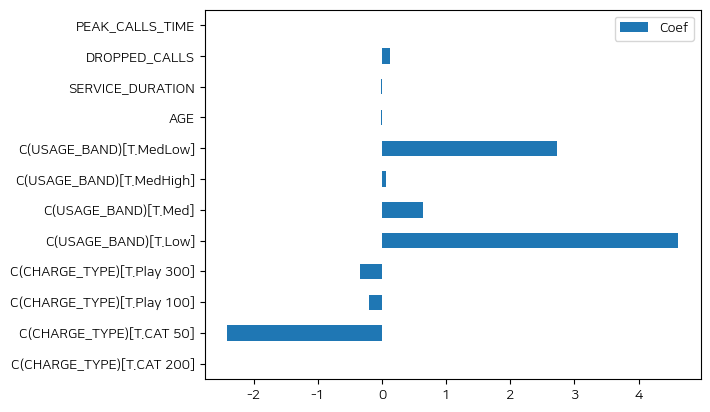

In [13]:
df_logistic_coef = pd.DataFrame({"Coef": log_result.params.values[1:]}, index = log_model.exog_names[1:])
df_logistic_coef.plot.barh(y = "Coef")

### 결론 도출

모델의 정확도는 81.9%에서 83.9%로 높았지만, 실제 이탈 고객을 예측하는 재현율은 20%대 초반으로 매우 낮았다.<br>
이는 이탈데이터의 균형이 맞지 않아 잘못 예측하고 있는 것을 나타낸다.<br>
로지스틱 회귀 분석 결과, 사용량이 낮은 고객이 이탈 위험이 가장 높았다.<br>
또힌 고객의 나이와 피크 시간 통화 시간 또한 이탈에 유의미한 경향을 보였다.<br>
따라서 사용량 낮은 그룹을 중심으로 하는 집중적인 이탈 방지 전략을 즉시 실행해야 한다.<br>

## 의사결정나무

### 추가적인 전처리

In [14]:
df_raw_dummy = pd.get_dummies(df_raw)
df_raw_dummy.head()

,CHURN,AGE,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME,...,HANDSET_S50,HANDSET_S80,HANDSET_SOP10,HANDSET_SOP20,HANDSET_WC95,USAGE_BAND_High,USAGE_BAND_Low,USAGE_BAND_Med,USAGE_BAND_MedHigh,USAGE_BAND_MedLow
0,0,31,33.33,6,218,379.8,9,21.6,366,632.4,...,0,0,0,0,0,0,0,1,0,0
1,0,27,30.87,10,373,656.4,11,28.0,411,810.4,...,1,0,0,0,0,0,0,1,0,0
2,0,27,49.40,11,260,582.0,0,0.0,265,614.1,...,0,0,0,0,0,0,0,1,0,0
3,0,61,48.60,1,294,661.8,14,101.5,326,844.0,...,0,0,0,0,0,0,0,1,0,0
4,0,52,56.03,0,221,555.6,7,25.0,274,673.0,...,1,0,0,0,0,0,0,1,0,0


In [15]:
df_raw_x = df_raw_dummy.drop("CHURN", axis = 1, inplace = False)
df_raw_y = df_raw_dummy["CHURN"] 

df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(
    df_raw_x, df_raw_y, test_size = 0.3, random_state = 1234) 

print("분할 전 설명변수 데이터 :", df_raw_x.shape)
print("분할 후 설명변수 데이터 :Train", df_train_x.shape, "  Test",df_test_x.shape)

분할 전 설명변수 데이터 : (930, 32)
분할 후 설명변수 데이터 :Train (651, 32)   Test (279, 32)


### 데이터 분리/ 분할

In [16]:
print(df_raw.value_counts(["CHURN"]),"\n")
print("CHURN=1 비율  ", df_raw.value_counts(df_raw["CHURN"]==1)/len(df_raw))

CHURN
0        750
1        180
dtype: int64 

CHURN=1 비율   CHURN
False    0.806452
True     0.193548
dtype: float64


In [17]:
# df_train_y의 고유 값과 개수를 확인합니다.
print("df_train_y 클래스 개수:\n", df_train_y.value_counts())
print("df_train_y 고유 값:\n", df_train_y.unique())

df_train_y 클래스 개수:
 0    515
1    136
Name: CHURN, dtype: int64
df_train_y 고유 값:
 [0 1]


In [18]:
sm = SMOTE(sampling_strategy='auto', random_state=1234)

x_resampled, y_resampled = sm.fit_resample(df_train_x,df_train_y)

print('Over-Sampling 전:\n',df_train_y.value_counts(),"\n")
print('Over-Sampling 후 Train X: {}'.format(x_resampled.shape))
print('Over-Sampling 후 Train Y: {} \n'.format(y_resampled.shape))

print("Over-Sampling 후 '1':{}".format(sum(y_resampled==1)))
print("Over-Sampling 후 '0':{}".format(sum(y_resampled==0)))

Over-Sampling 전:
 0    515
1    136
Name: CHURN, dtype: int64 

Over-Sampling 후 Train X: (1030, 32)
Over-Sampling 후 Train Y: (1030,) 

Over-Sampling 후 '1':515
Over-Sampling 후 '0':515


In [19]:
df_resampled = pd.concat([x_resampled,y_resampled], axis=1)
print(df_resampled.head())

   AGE  SERVICE_DURATION  DROPPED_CALLS  PEAK_CALLS_NO  PEAK_CALLS_TIME  \
0   40             36.00              2            556           1436.4   
1   41             45.33             11             73            403.2   
2   26             55.07              0            546           1228.2   
3   24             50.83              2            249            445.2   
4   32             55.63             10            125            232.2   

   WEEKEND_CALLS_NO  WEEKEND_CALLS_TIME  TOTAL_CALLS_NO  TOTAL_CALLS_TIME  \
0                 8                74.0             736            1862.9   
1                15                39.0             204             962.4   
2                 0                 0.0             588            1294.8   
3                 6                15.0             274             527.1   
4                 4               112.8             159             525.9   

   GENDER_F  ...  HANDSET_S80  HANDSET_SOP10  HANDSET_SOP20  HANDSET_WC95  \
0        

### 모델 생성

In [20]:
tree_uncust = DecisionTreeClassifier(random_state=1234 )
tree_uncust.fit(x_resampled, y_resampled)

print("Accuracy on training set: {:.3f}".format(tree_uncust.score(x_resampled, y_resampled)))
print("Accuracy on test set: {:.3f}".format(tree_uncust.score(df_test_x, df_test_y)))

Accuracy on training set: 1.000
Accuracy on test set: 0.867


### 하이퍼파라미터 조정

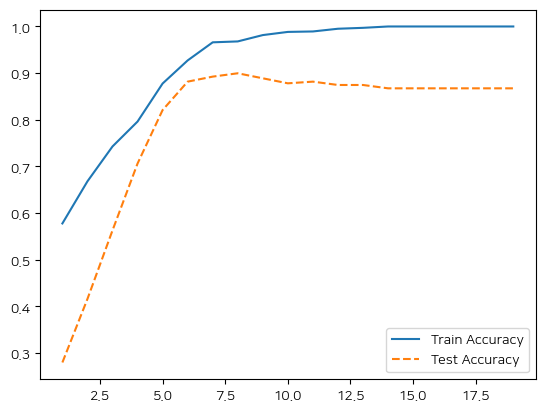

In [21]:
train_accuracy = []; test_accuracy = []

para_depth = [depth for depth in range(1, 20)]

for v_max_depth in para_depth:
    tree = DecisionTreeClassifier(max_depth = v_max_depth, random_state=1234)
    tree.fit(x_resampled, y_resampled)
    train_accuracy.append(tree.score(x_resampled, y_resampled))
    test_accuracy.append(tree.score(df_test_x, df_test_y))

plt.plot(para_depth, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_depth, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.legend()

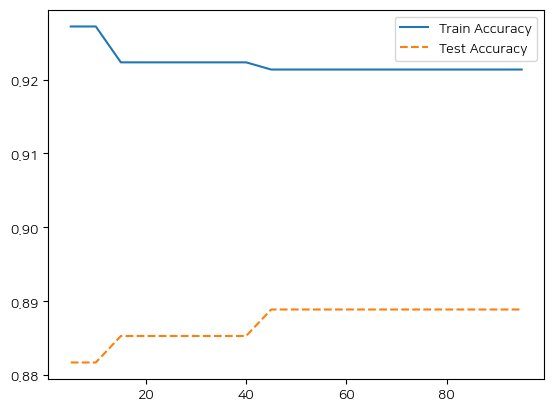

In [22]:
train_accuracy = []; test_accuracy = []
para_split = [n_split*5 for n_split in range(1, 20)]

for v_min_samples_split in para_split:
    tree = DecisionTreeClassifier(min_samples_split = v_min_samples_split, max_depth=6, random_state=1234)
    tree.fit(x_resampled, y_resampled)
    train_accuracy.append(tree.score(x_resampled, y_resampled))
    test_accuracy.append(tree.score(df_test_x, df_test_y))

plt.plot(para_split, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_split, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.legend()

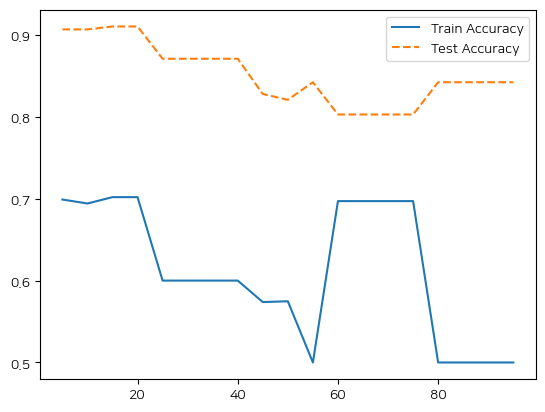

In [23]:
train_accuracy = []; test_accuracy = []

para_leaf = [n_leaf*5 for n_leaf in range(1,20)]

for v_min_samples_leaf in para_leaf:
    tree = DecisionTreeClassifier(min_samples_leaf = v_min_samples_leaf, min_samples_split=20, \
        max_depth=6, random_state=1234)
    tree.fit(df_train_x, df_train_y)
    train_accuracy.append(tree.score(x_resampled, y_resampled))
    test_accuracy.append(tree.score(df_test_x, df_test_y))

plt.plot(para_leaf, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_leaf, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.legend()

In [24]:
#앞선 그래프를 참고하여 하이퍼파라미터 튜닝 진행
para_depth = [depth for depth in range(5, 15)]
para_split = [n_split for n_split in range(20, 40)]
para_leaf = [n_leaf for n_leaf in range(50,80)]

estimator = DecisionTreeClassifier()
param_grid = {"max_depth": para_depth, "min_samples_split": para_split,
              "min_samples_leaf": para_leaf}
grid_dt = GridSearchCV(estimator, param_grid, scoring="accuracy", n_jobs = -1)
grid_dt.fit(x_resampled, y_resampled)

print("best estimator model: \n{}".format(grid_dt.best_estimator_))
print("\nbest parameter: \n{}".format(grid_dt.best_params_))
print("\nbest score: \n{}".format(grid_dt.best_score_.round(3)))

best estimator model: 
DecisionTreeClassifier(max_depth=6, min_samples_leaf=54, min_samples_split=20)

best parameter: 
{'max_depth': 6, 'min_samples_leaf': 54, 'min_samples_split': 20}

best score: 
0.84


### 최종 모델 선정

In [25]:
tree_final = DecisionTreeClassifier(max_depth=6, min_samples_split=54, min_samples_leaf=21, random_state=1234)
tree_final.fit(x_resampled, y_resampled)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=21, min_samples_split=54,
                       random_state=1234)

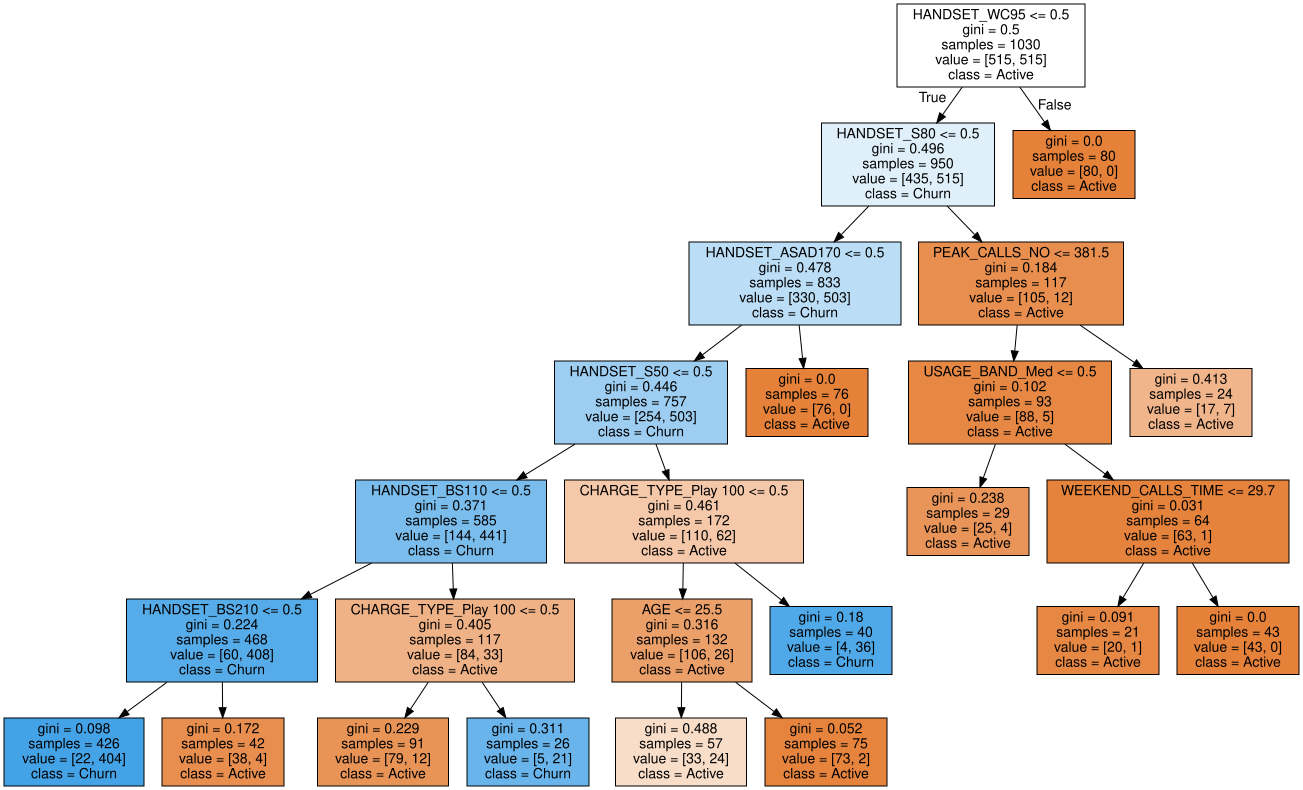

In [26]:
export_graphviz(tree_final, out_file="tree_final.dot", class_names = ["Active", "Churn"],
                feature_names = x_resampled.columns, impurity = True, filled = True)

with open("tree_final.dot") as f:
    dot_graph = f.read()
display(graphviz.Source(dot_graph))

### 모델 평가

In [27]:
y_pred = tree_final.predict(df_test_x)
print("Test Accuracy: {0:.3f}\n".format(tree_final.score(df_test_x, df_test_y)))
print("Test Confusion matrix: \n{}".format(confusion_matrix(df_test_y, y_pred)))

print(classification_report(df_test_y, y_pred, digits=3))

Test Accuracy: 0.878

Test Confusion matrix: 
[[219  16]
 [ 18  26]]
              precision    recall  f1-score   support

           0      0.924     0.932     0.928       235
           1      0.619     0.591     0.605        44

    accuracy                          0.878       279
   macro avg      0.772     0.761     0.766       279
weighted avg      0.876     0.878     0.877       279



In [28]:
df_importance = pd.DataFrame()
df_importance["Feature"] = x_resampled.columns
df_importance["Importance"] = tree_final.feature_importances_

df_importance.sort_values("Importance", ascending=False, inplace = True)
df_importance.round(3)

,Feature,Importance
18,HANDSET_BS110,0.172
16,HANDSET_ASAD170,0.161
19,HANDSET_BS210,0.147
23,HANDSET_S80,0.136
14,CHARGE_TYPE_Play 100,0.129
26,HANDSET_WC95,0.114
22,HANDSET_S50,0.108
0,AGE,0.027
3,PEAK_CALLS_NO,0.006
29,USAGE_BAND_Med,0.002


Text(0, 0.5, '설명변수')

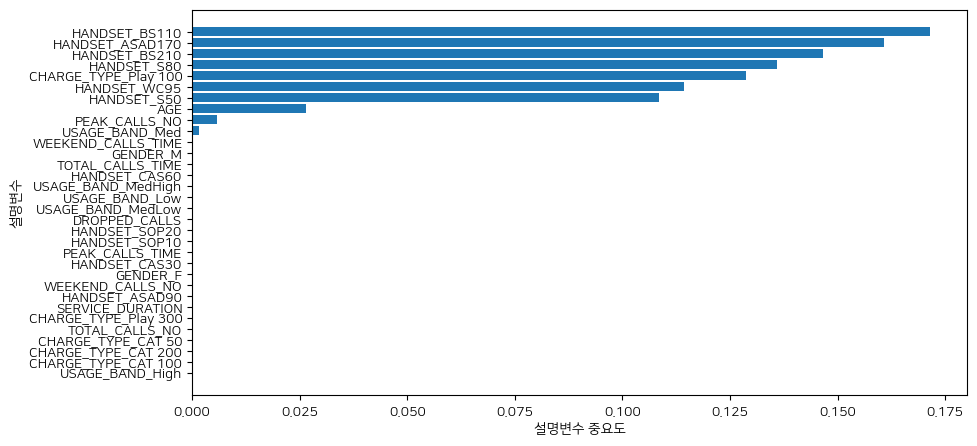

In [29]:
df_importance.sort_values("Importance", ascending=True, inplace = True)
coordinates = range(len(df_importance))

plt.figure(figsize=(10,5))
plt.barh(y = coordinates, width = df_importance["Importance"])
plt.yticks(coordinates, df_importance["Feature"])
plt.xlabel("설명변수 중요도")

plt.ylabel("설명변수")

### 결론 도출

의사결정나무에서 휴대폰 모델의 변수가 이탈 고객을 분류하는 데 가장 중요한 요인을 나타냈다.<br>
연속형 변수 중에서는 피크 시간 통화 횟수와 나이가 중요한 영향을 미쳤다.<br>
종합적인 정확도는 0.878로 높으며, f1스코어도 OVERSAMPLING의 영향으로 높게 나타났다.<br>
결론적으로, 통신사는 특정 휴대폰 모델을 사용하는 고객층을 대상으로 전략 수립이 필요해 보인다.

## 랜덤포레스트

### 데이터 분할

In [30]:
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(
    df_raw_x, df_raw_y, test_size = 0.3, random_state = 1234) 

print("분할 전 설명변수 데이터 :", df_raw_x.shape)
print("분할 후 설명변수 데이터 :Train", df_train_x.shape, "  Test",df_test_x.shape)

분할 전 설명변수 데이터 : (930, 32)
분할 후 설명변수 데이터 :Train (651, 32)   Test (279, 32)


In [31]:
print(df_raw.value_counts(["CHURN"]),"\n")
print("CHURN=1 비율  ", df_raw.value_counts(df_raw["CHURN"]==1)/len(df_raw))

CHURN
0        750
1        180
dtype: int64 

CHURN=1 비율   CHURN
False    0.806452
True     0.193548
dtype: float64


In [32]:
# Smote 활용한 Oversampling
sm = SMOTE(sampling_strategy='auto', random_state=1234)

x_resampled, y_resampled = sm.fit_resample(df_train_x,df_train_y)

print('Over-Sampling 전:\n',df_train_y.value_counts(),"\n")
print('Over-Sampling 후 Train X: {}'.format(x_resampled.shape))
print('Over-Sampling 후 Train Y: {} \n'.format(y_resampled.shape))

print("Over-Sampling 후 '1':{}".format(sum(y_resampled==1)))
print("Over-Sampling 후 '0':{}".format(sum(y_resampled==0)))

Over-Sampling 전:
 0    515
1    136
Name: CHURN, dtype: int64 

Over-Sampling 후 Train X: (1030, 32)
Over-Sampling 후 Train Y: (1030,) 

Over-Sampling 후 '1':515
Over-Sampling 후 '0':515


### 모델 생성 

In [33]:
rf_uncust = RandomForestClassifier(random_state=1234)
rf_uncust.fit(x_resampled, y_resampled)

print("Accuracy on training set: {:.3f}".format(rf_uncust.score(x_resampled, y_resampled)))
print("Accuracy on test set: {:.3f}".format(rf_uncust.score(df_test_x, df_test_y)))

Accuracy on training set: 1.000
Accuracy on test set: 0.889


### 하이퍼파라미터 조정

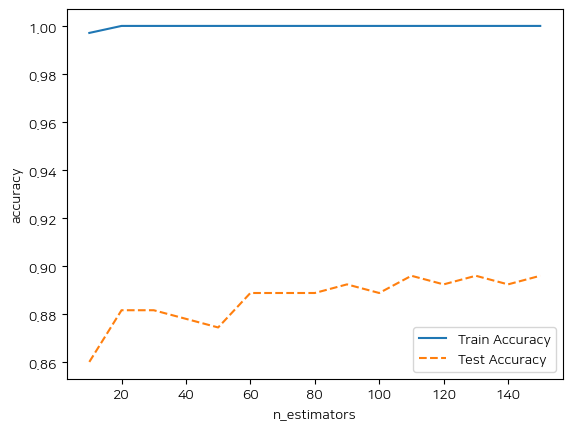

In [34]:
train_accuracy = []; test_accuracy = []

para_n_tree = [n_tree * 10 for n_tree in range(1, 16)]

for v_n_estimators in para_n_tree:
    rf = RandomForestClassifier(n_estimators = v_n_estimators, random_state = 1234)
    rf.fit(x_resampled, y_resampled)
    train_accuracy.append(rf.score(x_resampled, y_resampled))
    test_accuracy.append(rf.score(df_test_x, df_test_y))

plt.plot(para_n_tree, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_n_tree, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.xlabel("n_estimators"); plt.ylabel("accuracy")
plt.legend()

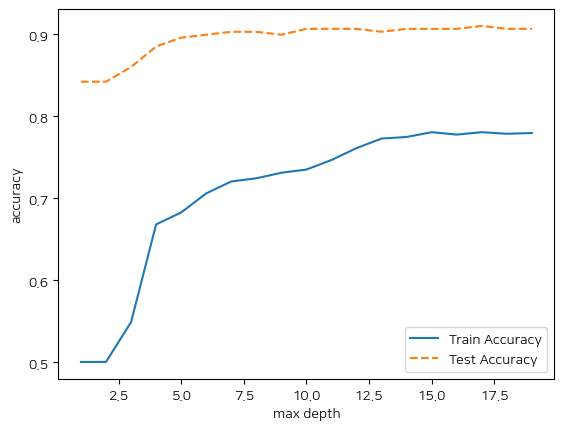

In [35]:
train_accuracy = []; test_accuracy = []

para_depth = [depth for depth in range(1, 20)]

for v_max_depth in para_depth:
    rf = RandomForestClassifier(max_depth = v_max_depth, n_estimators=110, random_state=1234)
    rf.fit(df_train_x, df_train_y)
    train_accuracy.append(rf.score(x_resampled, y_resampled))
    test_accuracy.append(rf.score(df_test_x, df_test_y))

plt.plot(para_depth, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_depth, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.xlabel("max depth"); plt.ylabel("accuracy")
plt.legend()

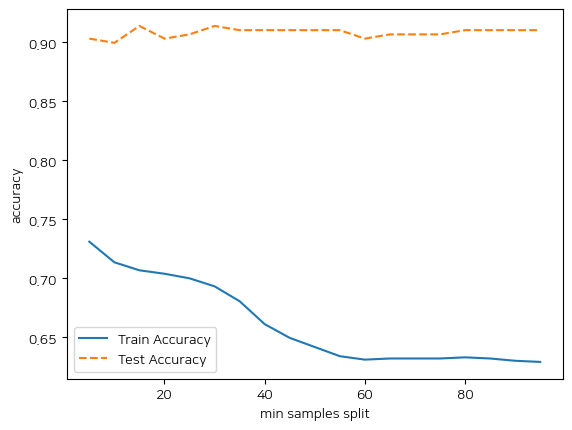

In [36]:
train_accuracy = []; test_accuracy = []

para_split = [n_split * 5 for n_split in range(1, 20)]

for v_min_samples_split in para_split:
    rf = RandomForestClassifier(min_samples_split = v_min_samples_split, max_depth=10,
                                n_estimators=110, random_state=1234)
    rf.fit(df_train_x, df_train_y)
    train_accuracy.append(rf.score(x_resampled, y_resampled))
    test_accuracy.append(rf.score(df_test_x, df_test_y))

plt.plot(para_split, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_split, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.xlabel("min samples split"); plt.ylabel("accuracy")
plt.legend()

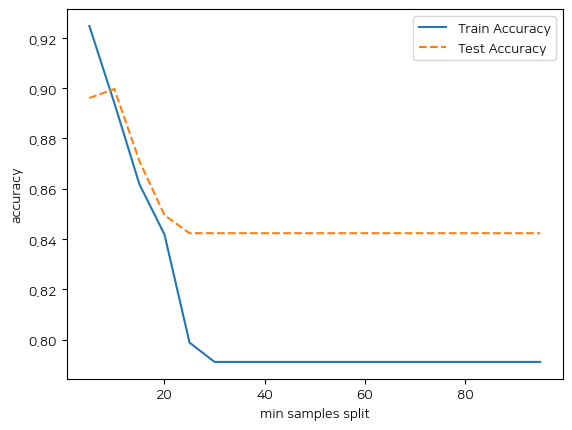

In [37]:
train_accuracy = []; test_accuracy = []

para_leaf = [n_leaf * 5 for n_leaf in range(1, 20)]

for v_min_samples_leaf in para_leaf:
    rf = RandomForestClassifier(min_samples_leaf = v_min_samples_leaf,
                                max_depth=10, n_estimators=110, random_state=1234)
    rf.fit(df_train_x, df_train_y)
    train_accuracy.append(rf.score(df_train_x, df_train_y))
    test_accuracy.append(rf.score(df_test_x, df_test_y))

plt.plot(para_split, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_split, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.xlabel("min samples split"); plt.ylabel("accuracy")
plt.legend()

In [38]:
estimator = RandomForestClassifier(n_estimators=110,random_state=1234)

para_depth = [depth for depth in range(15, 20)]
para_split = [n_split for n_split in range(10, 30)]
para_leaf = [n_leaf for n_leaf in range(0,20)]

param_grid = {"max_depth": para_depth, "min_samples_split": para_split,
              "min_samples_leaf": para_leaf}

grid_rf = GridSearchCV(estimator, param_grid, scoring="accuracy", n_jobs = -1)
grid_rf.fit(x_resampled, y_resampled)

print("best estimator model: \n{}".format(grid_rf.best_estimator_))
print("\nbest parameter: \n{}".format(grid_rf.best_params_))
print("\nbest score: \n{}".format(grid_rf.best_score_.round(3)))

best estimator model: 
RandomForestClassifier(max_depth=16, min_samples_split=10, n_estimators=110,
                       random_state=1234)

best parameter: 
{'max_depth': 16, 'min_samples_leaf': 1, 'min_samples_split': 10}

best score: 
0.923


### 최종모델 선정

In [40]:
rf_final = RandomForestClassifier(min_samples_leaf=1, max_depth=16, n_estimators=110, random_state=1234)
rf_final.fit(df_train_x, df_train_y)


y_pred = rf_final.predict(df_test_x)


print("Accuracy on training set: {:.3f}".format(rf_final.score(df_train_x, df_train_y)))
print("Accuracy on test set: {:.3f}\n".format(rf_final.score(df_test_x, df_test_y)))
print("Confusion matrix: \n{}".format(confusion_matrix(df_test_y, y_pred)))
print(classification_report(df_test_y, y_pred, digits=3))

Accuracy on training set: 1.000
Accuracy on test set: 0.907

Confusion matrix: 
[[226   9]
 [ 17  27]]
              precision    recall  f1-score   support

           0      0.930     0.962     0.946       235
           1      0.750     0.614     0.675        44

    accuracy                          0.907       279
   macro avg      0.840     0.788     0.810       279
weighted avg      0.902     0.907     0.903       279



### 모델 평가

In [41]:
feature_names = df_train_x.columns

df_importance = pd.DataFrame()
df_importance["Feature"] = feature_names
df_importance["Importance"] = rf_final.feature_importances_

df_importance.sort_values("Importance", ascending=False, inplace = True)
df_importance.round(3)

,Feature,Importance
17,HANDSET_ASAD90,0.144
2,DROPPED_CALLS,0.100
4,PEAK_CALLS_TIME,0.089
8,TOTAL_CALLS_TIME,0.075
1,SERVICE_DURATION,0.072
0,AGE,0.063
7,TOTAL_CALLS_NO,0.058
6,WEEKEND_CALLS_TIME,0.057
3,PEAK_CALLS_NO,0.056
20,HANDSET_CAS30,0.052


Text(0, 0.5, '설명변수')

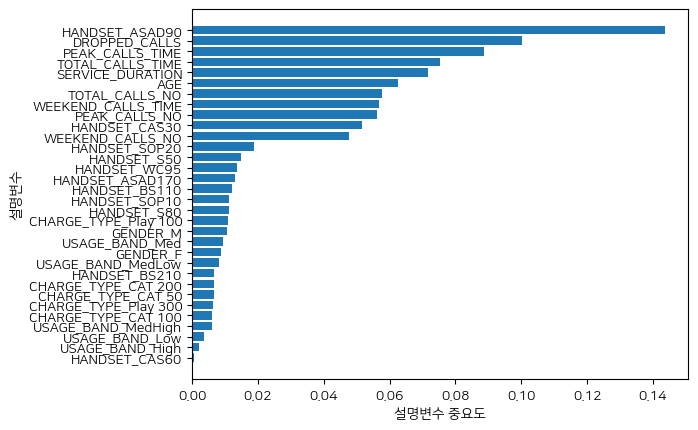

In [42]:
df_importance.sort_values("Importance", ascending=True, inplace = True)
coordinates = range(len(df_importance ))
plt.barh(y = coordinates, width = df_importance ["Importance"])
plt.yticks(coordinates, df_importance ["Feature"])
plt.xlabel("설명변수 중요도")
plt.ylabel("설명변수")

랜덤 포레스트 모델의 훈련 정확도는 100%로 과도하게 학습되었으나, 테스트 정확도도 90.7%로 높은 예측 성능을 보였다.<br>
이탈 고객에 대한 재현율은 61.4%로, 로지스틱 회귀 모델 대비 이탈 고객을 훨씬 더 잘 예측했습니다.<br>
변수 중요도 분석에서는 의사결정나무와 동일하게 휴대폰 모델 관련 변수들이 가장 중요한 예측 요인이었다.<br>
결론적으로 OVERSAMPLING을 사용한 경우에 안정적인 성능을 보여주었고, 그 중 랜덤포레스트가 가장 우수한 성능을 보였다.<br>
그러므로 기업은 통화의 품질과 휴대폰 기종에 신경을 써야한다는 결론을 도출할 수 있었다.